#1. Importing Required Libraries:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

# 2. Loading the Dataset:

In [ ]:
from google.colab import files

# Upload the file
uploaded = files.upload()

# After uploading, you can read the file with pandas
import pandas as pd

# Replace 'filename.csv' with the name of your uploaded file
df = pd.read_csv('insurance.csv')




Saving insurance.csv to insurance.csv


#3. Overview of the Dataset:

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Get descriptive statistics of numerical columns
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#4. Checking for Missing Values:

In [ ]:
# Check for missing values in the dataset
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# 5. Data Type Checks:


In [ ]:
# Check for data types and convert if necessary
df['age'] = df['age'].astype(int)
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')


#6. Univariate Analysis:


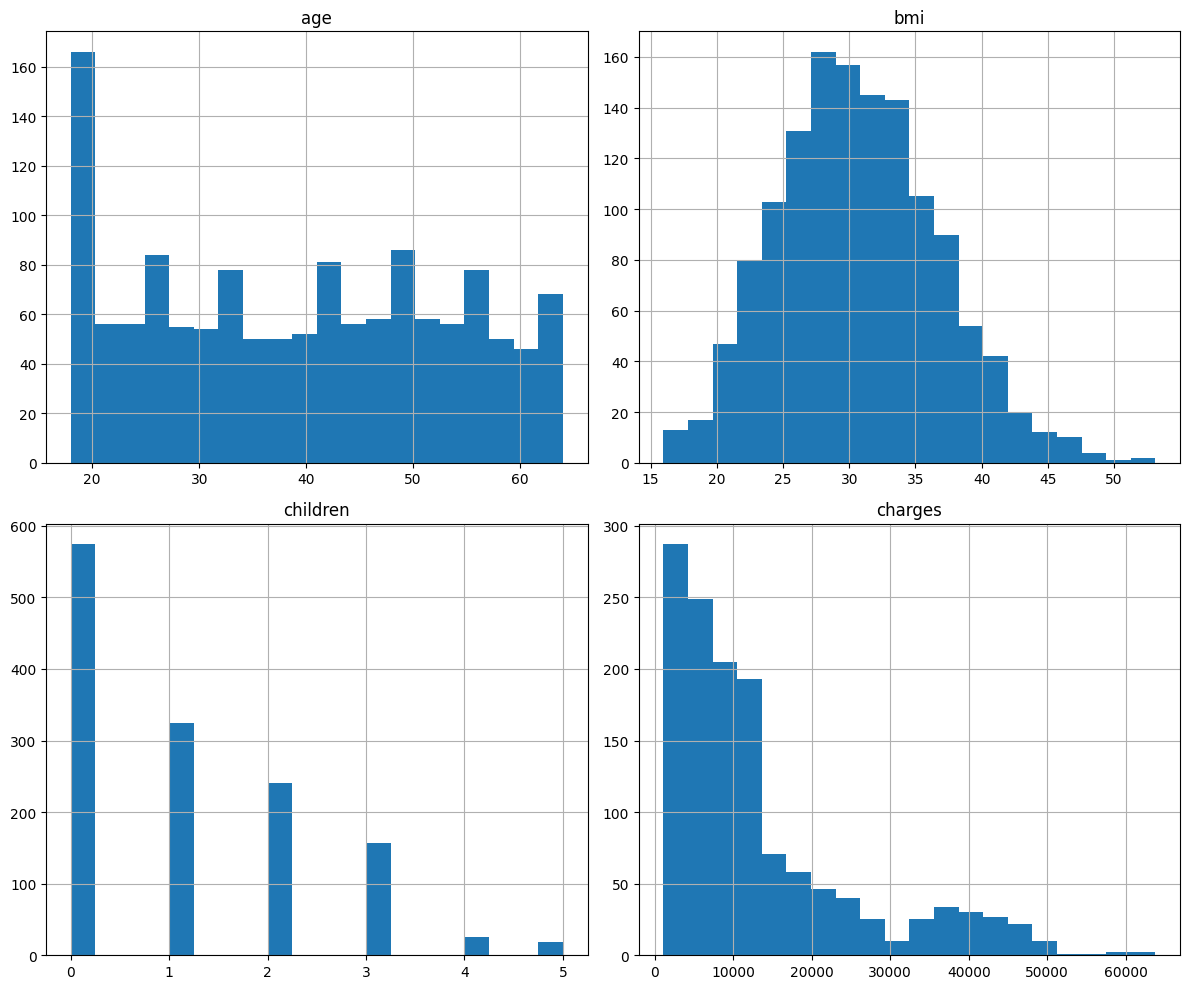

In [ ]:
# Plot histograms for all numerical features
df.hist(bins=20, figsize=(12, 10))
plt.tight_layout()
plt.show()


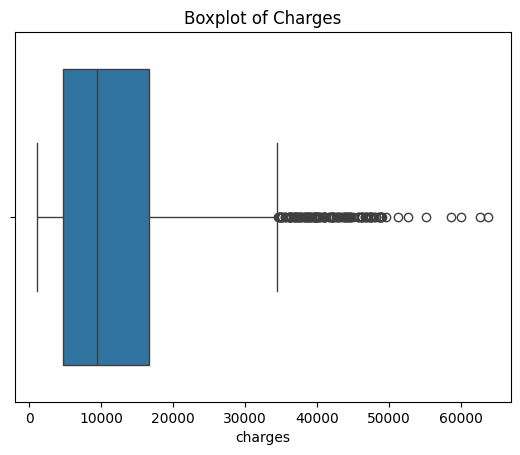

In [ ]:
# Boxplot for the 'charges' column to identify outliers
sns.boxplot(x='charges', data=df)
plt.title('Boxplot of Charges')
plt.show()


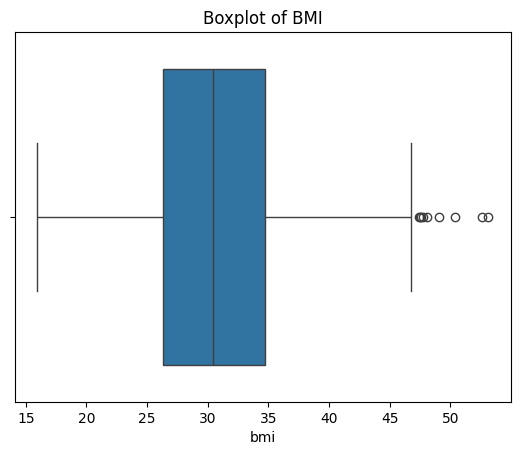

In [ ]:
sns.boxplot(x='bmi', data=df)
plt.title('Boxplot of BMI')
plt.show()


#7. Bivariate Analysis:

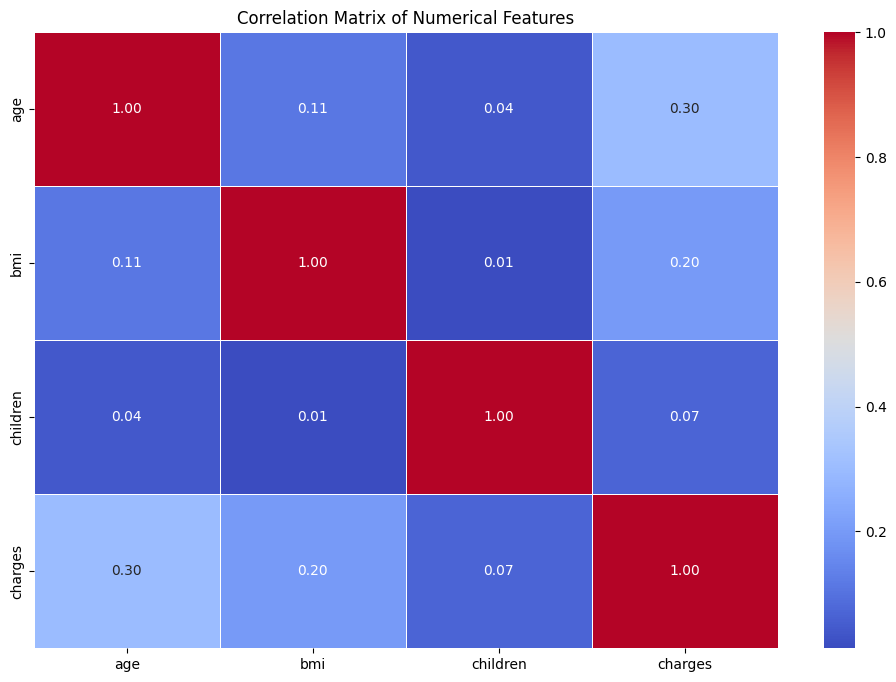

In [ ]:
# Calculate correlation matrix for numerical features only
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

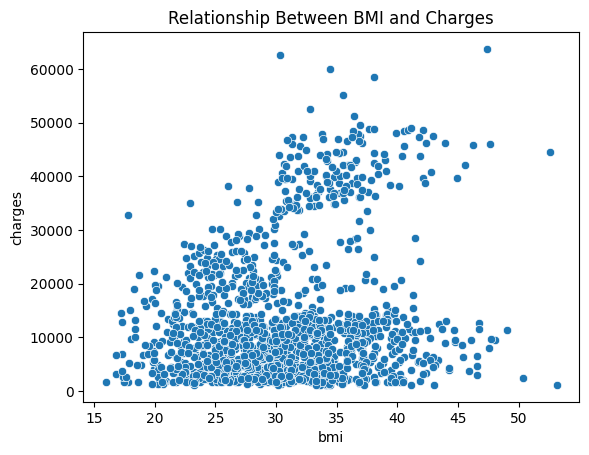

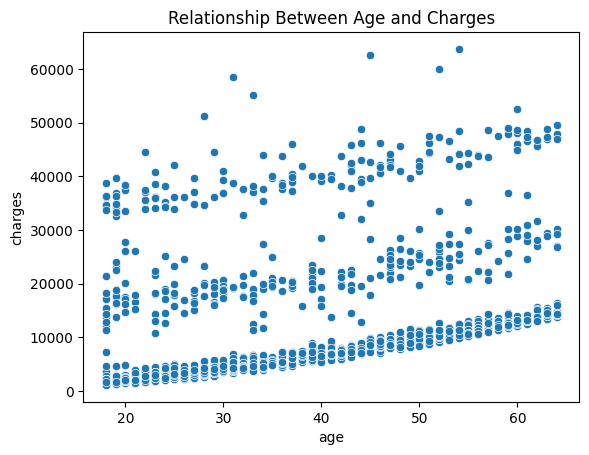

In [ ]:
# Scatter plot between BMI and Charges
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('Relationship Between BMI and Charges')
plt.show()

# Scatter plot between Age and Charges
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Relationship Between Age and Charges')
plt.show()


#8. Categorical Data Analysis:

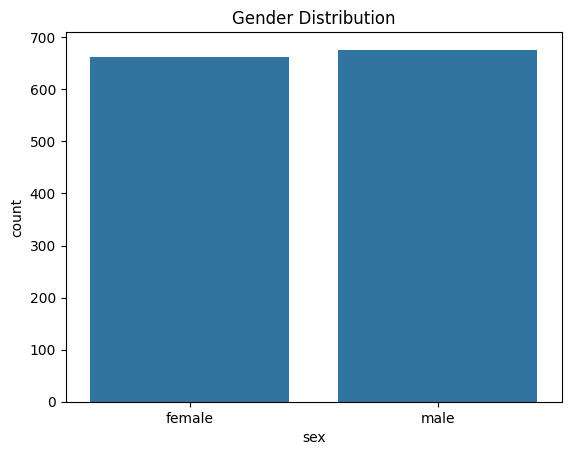

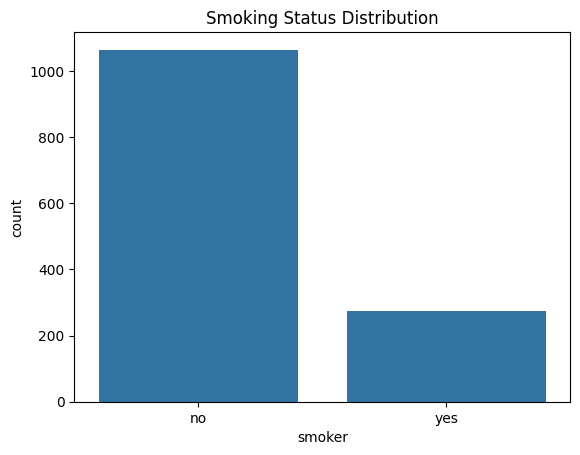

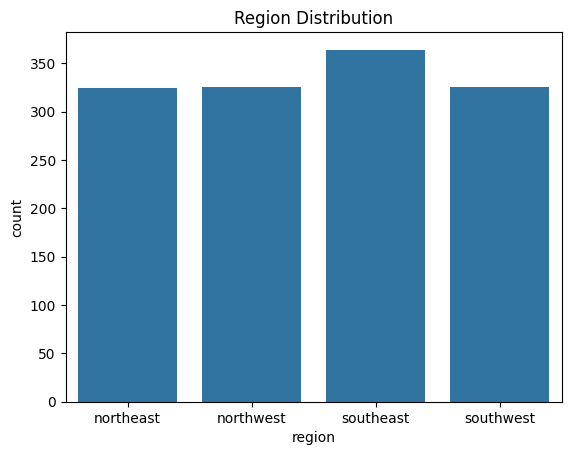

In [ ]:
# Countplot for 'sex'
sns.countplot(x='sex', data=df)
plt.title('Gender Distribution')
plt.show()

# Countplot for 'smoker'
sns.countplot(x='smoker', data=df)
plt.title('Smoking Status Distribution')
plt.show()

# Countplot for 'region'
sns.countplot(x='region', data=df)
plt.title('Region Distribution')
plt.show()


#9. Handling Outliers (Advanced):

In [ ]:
# Calculate Z-scores using scipy.stats.zscore
from scipy.stats import zscore

z_scores = np.abs(zscore(df[['age', 'bmi', 'charges']]))

# Set threshold for Z-score (e.g., 3)
df_no_outliers = df[(z_scores < 3).all(axis=1)]

# Check shape before and after removing outliers
print(f'Original Data: {df.shape}')
print(f'After Removing Outliers: {df_no_outliers.shape}')

Original Data: (1338, 7)
After Removing Outliers: (1327, 7)


In [ ]:
# Calculate IQR for numerical columns
Q1 = df[['age', 'bmi', 'charges']].quantile(0.25)
Q3 = df[['age', 'bmi', 'charges']].quantile(0.75)
IQR = Q3 - Q1

# Filter out rows where values are outside of the IQR range
df_no_outliers = df[~((df[['age', 'bmi', 'charges']] < (Q1 - 1.5 * IQR)) | (df[['age', 'bmi', 'charges']] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check the new dataset
print(f'Original Data: {df.shape}')
print(f'After Removing Outliers: {df_no_outliers.shape}')


Original Data: (1338, 7)
After Removing Outliers: (1193, 7)


# 10. Advanced Statistical Analysis

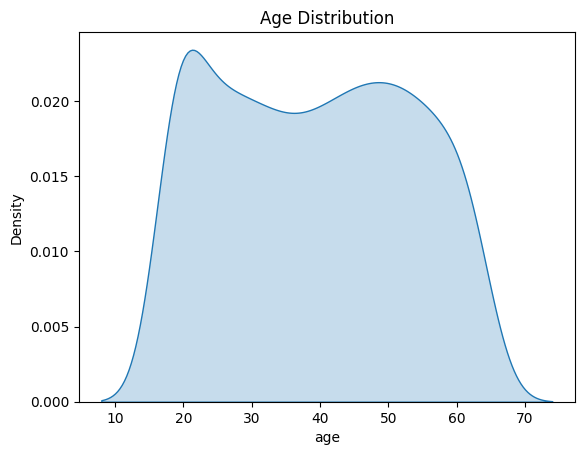

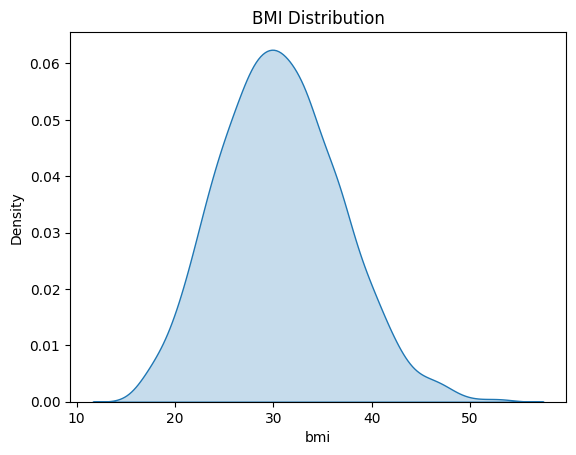

In [ ]:
# KDE Plot for Age distribution
sns.kdeplot(df['age'], shade=True)
plt.title('Age Distribution')
plt.show()

# KDE Plot for BMI distribution
sns.kdeplot(df['bmi'], shade=True)
plt.title('BMI Distribution')
plt.show()


In [ ]:
from scipy.stats import shapiro

# Test for normality on 'charges' column
stat, p = shapiro(df['charges'])
print(f'Statistic: {stat}, p-value: {p}')

# If p-value < 0.05, the data is not normally distributed


Statistic: 0.8146881157362383, p-value: 1.1505226334932036e-36


#11. Feature Engineering

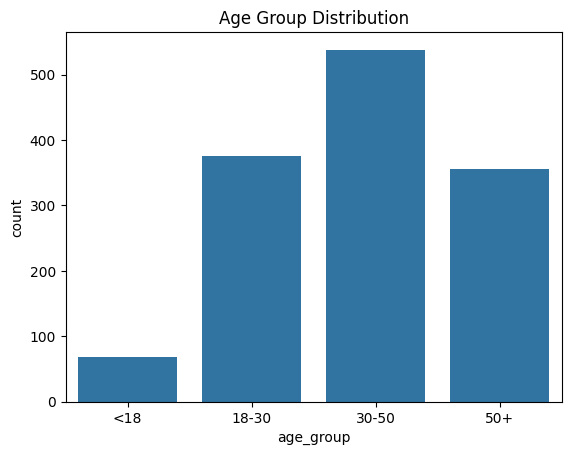

In [ ]:
# Create a new feature, 'age_group', based on age
bins = [0, 18, 30, 50, 100]
labels = ['<18', '18-30', '30-50', '50+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Visualize the new 'age_group' feature
sns.countplot(x='age_group', data=df)
plt.title('Age Group Distribution')
plt.show()


#12. Save the Cleaned Dataset:

In [ ]:
# Save the cleaned dataset
df.to_csv('cleaned_data.csv', index=False)


#13. built a simple linear regression model to predict the charges




In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load the cleaned dataset
data = pd.read_csv("cleaned_data.csv")

# Optional: Preview the data to confirm it's loaded correctly
print(data.head())


   age     sex     bmi  children smoker     region      charges age_group
0   19  female  27.900         0    yes  southwest  16884.92400     18-30
1   18    male  33.770         1     no  southeast   1725.55230       <18
2   28    male  33.000         3     no  southeast   4449.46200     18-30
3   33    male  22.705         0     no  northwest  21984.47061     30-50
4   32    male  28.880         0     no  northwest   3866.85520     30-50


In [ ]:
print(data.isnull().sum())


age          0
sex          0
bmi          0
children     0
smoker       0
region       0
charges      0
age_group    0
dtype: int64


In [ ]:
data = pd.get_dummies(data, drop_first=True)


In [ ]:
X = data[['age', 'bmi', 'children', 'smoker_yes']]  # Example features
y = data['charges']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


Mean Squared Error: 33981653.95019776
R-squared: 0.7811147722517886


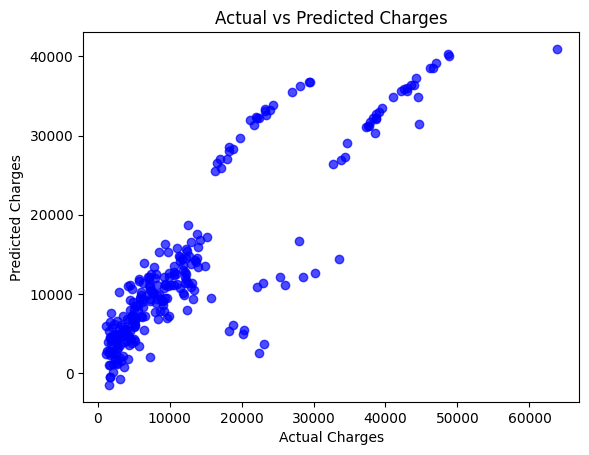

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()


In [ ]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)


             Coefficient
age           257.071158
bmi           327.522631
children      427.199971
smoker_yes  23653.211646


In [ ]:
# Example: Predict charges for a new person
# Replace these values with actual feature values
new_person = pd.DataFrame({
    'age': [19],        # Age
    'bmi': [25],      # BMI
    'children': [0],    # Number of children
    'smoker_yes': [1]    # Smoker status (1 for 'yes', 0 for 'no')
         })

# Make the prediction using your trained model
predicted_charge = model.predict(new_person)
print("Predicted Medical Charge:", predicted_charge[0])

Predicted Medical Charge: 24608.554350607963
